## 4.3 앙상블 학습

목표 : 다양한 분류기의 예측 결과 결합 -> 신뢰성이 높은 예측값을 얻음, 정형 데이터 분류 시 앙상블이 뛰어난 성능 가짐

XBBoost,LightGBM 등등이 있음

보팅, 배깅 - 투표를 통해 최종 예측 결과 결정
보팅 - 서로 다른 알고리즘을 가진 분류기를 결합
배깅 - 각각 분류기가 모두 같은 유형의 알고리즘 기반

### 보팅 유형 - 하드 보팅, 소프트 보팅

하드보팅을 이용한 분류는 다수결 어ㅜㄴ칙과 비슷함, 예측 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 보팅 결괏값으로 선정하는 것

소프트 보팅은 분류기들의 레이블값 결정 확률을 모두 더하고 이를 평균해서 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결과값으로 선정

## 보팅 분류기

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

cancer=load_breast_cancer()
data_df=pd.DataFrame(cancer.data,columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [12]:
lr_clf=LogisticRegression(solver='liblinear')
knn_clf=KNeighborsClassifier(n_neighbors=8)
vo_clf=VotingClassifier( estimators=[('LR',lr_clf),('KNN',knn_clf)],voting='soft')
X_train,X_test,y_train,y_test=train_test_split(cancer.data,cancer.target,test_size=0.2,random_state=156)
vo_clf.fit(X_train,y_train)
pred=vo_clf.predict(X_test)
print('Voting 분류기 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

classifiers=[lr_clf,knn_clf]
for classifier in classifiers:
    classifier.fit(X_train,y_train)
    pred=classifier.predict(X_test)
    class_name=classifier.__class__.__name__
    print('{0} 정확도 :{1:.4f}'.format(class_name,accuracy_score(y_test,pred)))

Voting 분류기 정확도:0.9561
LogisticRegression 정확도 :0.9474
KNeighborsClassifier 정확도 :0.9386


## 04. 랜덤 포레스트

배깅 - 같은 알고리즘으로 여러개의 분류기를 만들어 보팅으로 최종결정하는 알고리즘(ex.랜덤포레스트)

랜덤포레스트는 여러개의 결정 트리 분류기가 전체 데이터에서 배깅방식으로 각자의 데이터를 샘플링해 개별적으로 학습을 수행한 뒤 최종적으로 모든 분류기가 보팅을 통해 예측 결정을 하게 됨

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def get_human_dataset():
    # feature 이름 로딩
    feature_name_df = pd.read_csv('features.txt', sep='\s+', header=None, names=['index', 'feature_name'])
    feature_names = feature_name_df['feature_name'].values


    X_train = pd.read_csv('X_train.txt', sep='\s+', header=None)
    X_train.columns = feature_names
    y_train = pd.read_csv('y_train.txt', sep='\s+', header=None)
    y_train.columns = ['action']


    X_test = pd.read_csv('X_test.txt', sep='\s+', header=None)
    X_test.columns = feature_names
    y_test = pd.read_csv('y_test.txt', sep='\s+', header=None)
    y_test.columns = ['action']

    X = pd.concat([X_train, X_test], axis=0)
    y = pd.concat([y_train, y_test], axis=0)

    from sklearn.model_selection import train_test_split
    return train_test_split(X, y, test_size=0.2, random_state=42)


X_train, X_test, y_train, y_test = get_human_dataset()


rf_clf=RandomForestClassifier(random_state=0,max_depth=8)
rf_clf.fit(X_train,y_train)
pred=rf_clf.predict(X_test)
accuracy=accuracy_score(y_test,pred)
print('랜덤 포레스트 정확도:{0:.4f}'.format(accuracy))

랜덤 포레스트 정확도:0.9631


In [17]:
from sklearn.model_selection import GridSearchCV
params={
    'max_depth':[8,16,24],
    'min_samples_leaf':[1,6,12],
    'min_samples_split':[2,8,16]
}
rf_clf=RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1)
grid_cv=GridSearchCV(rf_clf,param_grid=params,cv=2,n_jobs=-1)
grid_cv.fit(X_train,y_train)

print('최적 하이퍼 파라미터:\n',grid_cv.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 24, 'min_samples_leaf': 1, 'min_samples_split': 2}
최고 예측 정확도:0.9689


In [19]:
rf_clf1=RandomForestClassifier(n_estimators=100,min_samples_leaf=6,max_depth=16,
                               min_samples_split=2,random_state=0)
rf_clf1.fit(X_train,y_train)
pred=rf_clf1.predict(X_test)
print('예측 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도:0.9714


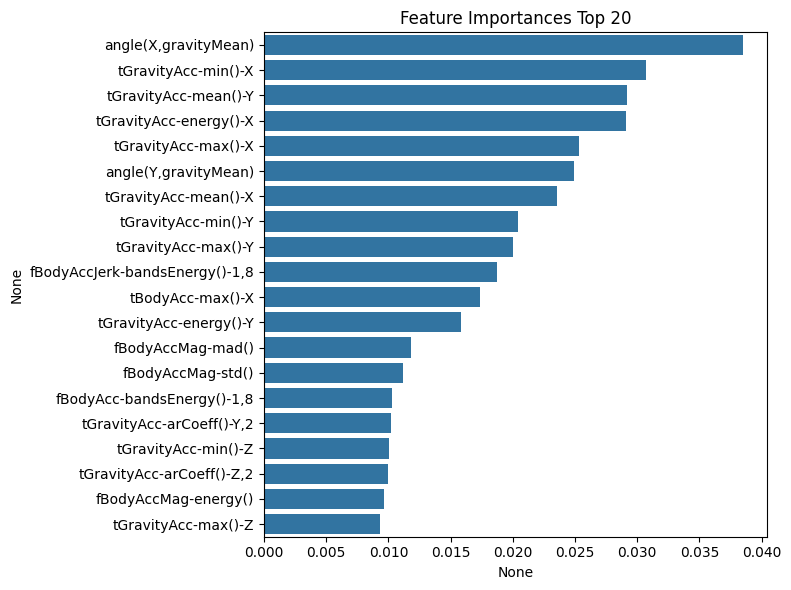

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline


ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8, 6))
plt.title('Feature Importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.tight_layout()
plt.show()



## 5. GBM 

부스팅 알고리즘 : 여러개의 약한 학습기를 순차적으로 학습,예측하며 잘못 예측한 데이터 가중치 부여하며 부스팅 수행하는 대표적 알고리즘

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 기간: {0:.1f}초'.format(time.time() - start_time))


## 6. XBBoost

트리 기반의 앙상블 학습에서 좋음
GBM단점(느린 수행,과적합 규제) 해결한 것


In [55]:
import xgboost as xgb
from xgboost import XGBClassifier

In [56]:
import xgboost
print(xgboost.__version__)

1.5.0


In [57]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset=load_breast_cancer()
features=dataset.data
labels=dataset.target
cancer_df=pd.DataFrame(data=features,columns=dataset.feature_names)
cancer_df['target']=labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [58]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [59]:
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X_features,y_label,test_size=0.2,random_state=156)
X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=156)
print(X_train.shape,X_test.shape)
print(X_tr.shape,X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [60]:
dtr = xgb.DMatrix(data=X_tr.values, label=y_tr.values)
dval = xgb.DMatrix(data=X_val.values, label=y_val.values)
dtest = xgb.DMatrix(data=X_test.values, label=y_test.values)


In [61]:
params={'max_depth':3,
        'eta':0.05,
        'objectives':'binary:logistic',
        'eval_metric':'logloss'
       }
num_rounds=400

In [62]:
eval_list=[(dtr,'train'),(dval,'eval')]
xgb_model=xgb.train(params,dtrain=dtr,num_boost_round=num_rounds, early_stopping_rounds=50,evals=eval_list)

[22:24:01] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.0/src/learner.cc:576: 
Parameters: { "objectives" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[0]	train-logloss:0.64853	eval-logloss:0.65930
[1]	train-logloss:0.60826	eval-logloss:0.63160
[2]	train-logloss:0.57127	eval-logloss:0.60798
[3]	train-logloss:0.53723	eval-logloss:0.58486
[4]	train-logloss:0.50618	eval-logloss:0.56483
[5]	train-logloss:0.47729	eval-logloss:0.54714
[6]	train-logloss:0.45083	eval-logloss:0.52984
[7]	train-logloss:0.42513	eval-logloss:0.50945
[8]	train-logloss:0.40134	eval-logloss:0.49076
[9]	train-logloss:0.38012	eval-logloss:0.47865
[10]	train-logloss:0.35951	eval-logloss:0.46263
[11]	train-logloss:0.34034	eval-logloss:0.44788
[12]	train-logl

In [63]:
pred_probs=xgb_model.predict(dtest)
print('predict()수행 결과값을 10개만 표시, 예측 확률값으로 표시됨')
print(np.round(pred_probs[:10],3))

preds=[1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:',preds[:10])

predict()수행 결과값을 10개만 표시, 예측 확률값으로 표시됨
[ 0.705  0.058  0.53   0.574  0.999  1.007  1.008  1.009  0.978 -0.004]
예측값 10개만 표시: [1, 0, 1, 1, 1, 1, 1, 1, 1, 0]


In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [73]:
# 예측할 때 넘파이 배열로 전달하여 에러 방지
preds = gb_clf.predict(X_test.values)
pred_probs = gb_clf.predict_proba(X_test.values)[:, 1]

get_clf_eval(y_test, preds, pred_probs)


ValueError: X has 30 features, but GradientBoostingClassifier is expecting 561 features as input.

In [65]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print('정확도: {:.4f}, 정밀도: {:.4f}, 재현율: {:.4f}, F1: {:.4f}, AUC: {:.4f}'.format(
        accuracy, precision, recall, f1, roc_auc
    ))
preds = gb_clf.predict(X_test)
pred_probs = gb_clf.predict_proba(X_test)[:, 1]

# 평가
get_clf_eval(y_test, preds, pred_probs)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- area error
- compactness error
- concave points error
- concavity error
- fractal dimension error
- ...
Feature names seen at fit time, yet now missing:
- angle(X,gravityMean)
- angle(Y,gravityMean)
- angle(Z,gravityMean)
- angle(tBodyAccJerkMean),gravityMean)
- angle(tBodyAccMean,gravity)
- ...


In [67]:
get_clf_eval(y_test,preds,pred_probs)

정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740, F1: 0.9677, AUC: 0.9937


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

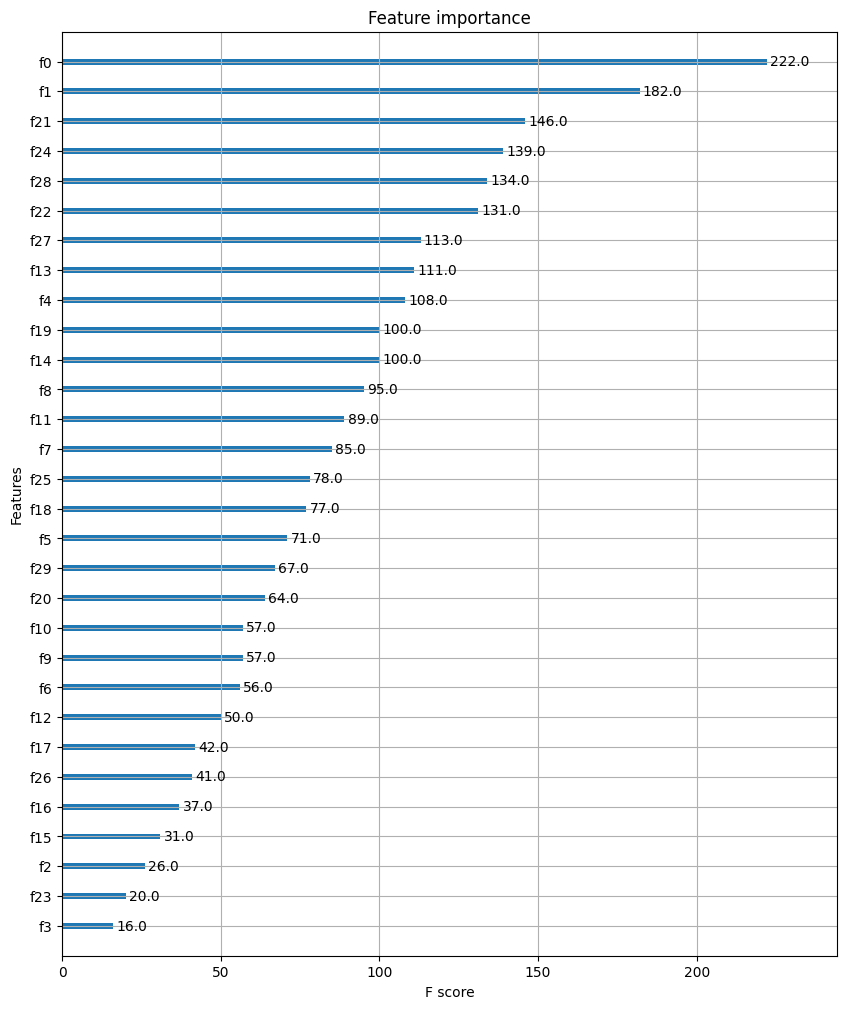

In [68]:
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_model,ax=ax)

In [72]:
from xgboost import XGBClassifier
import pandas as pd
xgb_wrapper=XGBClassifier(n_estimators=400,learning_rate=0.05,max_depth=3,eval_metric='logloss')
xgb_wrapper.fit(X_train,y_train,verbose=True)
w_preds=xgb_wrapper.predict(X_test)
w_preds_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test,w_preds,w_preds_proba)

AttributeError: module 'pandas' has no attribute 'Int64Index'

In [70]:
xgb_wrapper.fit(X_tr,y_tr,early_stopping_rounds=10,
                eval_metric="logloss",eval_set=evals,verbose=True)
ws10_preds=xgb_wrapper.predict(X_test)
ws10_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test,ws10_preds,ws10_pred_proba)

NameError: name 'evals' is not defined

NameError: name 'plt_importances' is not defined

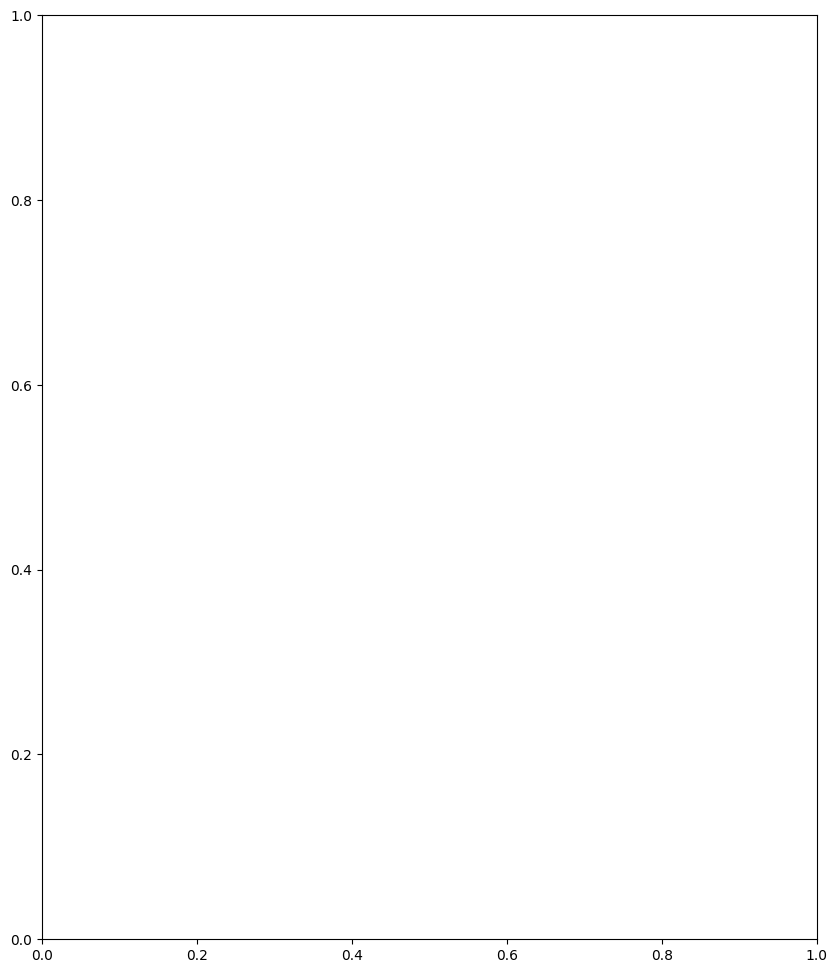

In [74]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline
fig,ax=plt.subplots(figsize=(10,12))
plt_importances(xgb_wrapper,ax=ax)

## 07. LightGBM

장점 : 학습 시간 훨씬 적음, 성능은 차이가 크게 안남(XGBoost와 비교해서), 
단점: 과적합 발생하기 쉬움(적은 데이터셋에 적용할 경우)
- 리프 중심 트리 분할 방식 사용(-> 오버피팅에 더 강한 구조)
최대 손실값을 가지는 리프 노드를 지속적으로 분할해 생성된 규칙트리는 학습반복할때마다 균형 트리 분할방식보다 예측 오류 손실을 최소화할 수 있음

In [75]:
import lightgbm
from lightgbm import LGBMClassifier

### LightGBM 하이퍼 파라미터

XGBoost와 많은 부분이 유사함(<-> 리프노드 분할되며 깊이가 깊어짐 -> 하이퍼 파라미터 설정 필요)

In [78]:
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset=load_breast_cancer()
cancer_df=pd.DataFrame(data=dataset.data,columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]

X_train,X_test,y_train,y_test=train_test_split(X_features,y_label,test_size=0.2,random_state=156)
X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=156)
lgbm_wrapper=LGBMClassifier(n_estimators=400,learning_rate=0.05)

evals=[(X_tr,y_tr),(X_val,y_val)]
lgbm_wrapper.fit(X_tr,y_tr,early_stopping_rounds=50,eval_metric="logloss",eval_set=evals,verbose=True)
preds=lgbm_wrapper.predict(X_test)
pred_proba=lgbm_wrapper.predict_proba(X_test)[:,1]

[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

In [77]:
get_clf_eval(y_test,preds,preds_proba)

NameError: name 'preds_proba' is not defined

NameError: name 'lgbm_wrapper' is not defined

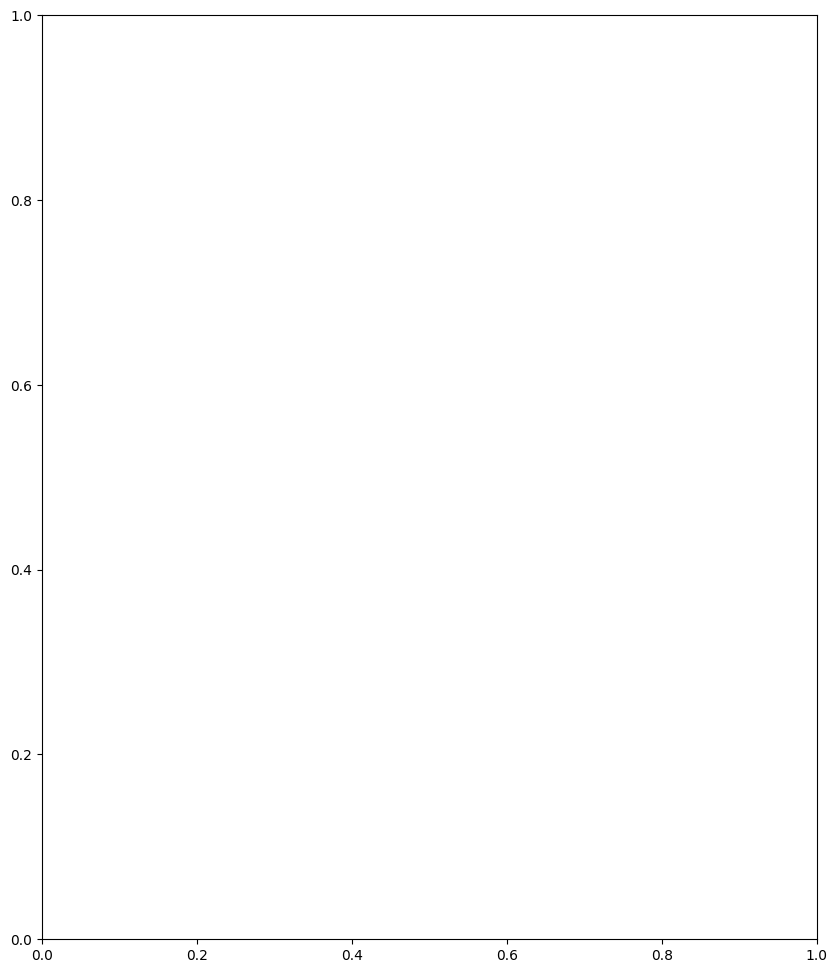

In [31]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper,ax=ax)

## 08.베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

In [82]:
params={'max_depth'=[10,20,30,40,50],'num_leaves'=[35,45,55,65],'colsample_bytree'=[0.5,0.6,0.7,0.8,0.9],'subsample'=[0.5,0.6,0.7,0.8,0.9],'min_child_weight'=[10,20,30,40],reg_alpha=[0.01,0.05,0.1]}

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (3776649861.py, line 1)

- 베이지안 최적화 :  목적 함수 식을 제대로 알 수 없는 블랙박스 형태의 함수에서 최대/최소함수 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으러 찾아주는 방식

In [ ]:
from hyperopt import hp
search_space={'x':hp.quniform('x',-10,10,1),'y':hp.quniform('y',-15,15,1)}

In [ ]:
from hyperopt import STATUS_OK
def objectives_func(search_space):
    x=search_space['x']
    y=search_space['y']
    retval=x**2 - 20**y

    return retval

In [ ]:
from hyperopt import fmin,tpe,Trials
trial_val=Trials()
best_01=fmin(fn=objective_func,space=search_space,algo=tpe.suggest,max_evals=5,trials=trial_val,rstate=np.random.default_rng(seed=0))
print('best:',best_01)

In [ ]:
trial_val=Trials()
best_02=fmin(fn=objectives_func,space=search_space,algo=tpe.suggest,max_evals=20,trial=trial_val,rstate=np.random.default_rng(seed=0))
print('best:',best_02)

In [ ]:
print(trial_val.results)

In [ ]:
print(trial_val.vals)

In [ ]:
import pandas as pd
losses=[loss_dict['loss'] for loss_dict in trial_val.results]
result_df=pd.DataFrame({'x':trial_val.vals['x'],'y':trial_val.vals['y']],'losses':losses})
result_df

In [ ]:
X_train,X_test,y_train,y_test=trian_test_split(X_features,y_label,test_size=0.2,random_state=156)
X_tr,X_val,y_tr,y_val=trian_test_split(X_train,y_train,test_size=0.1,random_state=156)

In [ ]:
from hyperopt import hp
xgb_search_space={'max_depth':hp.quniform('max_depth',5,20,1),
                  'min_child_weight':hp.quniform('min_child_weight',1,2,1),
                  'learning_rate':hp.uniform('learning_rate',0.01,0.2),
                  'colsample_bytree':hp.uniform('colsample_bytree',0.5,1),
                 }

In [ ]:
from sklearn.model_selection import cross_Val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK
def objectives_func(search_space):
    xgb_clf=XGBClassifier(n_estimators=100,max_depth=int(search_space['max_depth']),
                          min_child_weight=int(search_space['min_child_weight']),
                          learning_rate=search_space['learning_rate'],
                          colsample_bytree=search_space['colsample_bytree'],
                          eval_metric='logloss')
    accuracy=cross_val_score(xgb_clf,X_train,y_train,scoring='accuracy',cv=3)
    return {'loss':-1*np.mean(accuracy),'status':STATUS_OK}

In [ ]:
from hyperopt import fmin,tpe,Trials
trial_val=Trials()
best=fmin(fn=objective_func,
          space=xgb_search_space,
          algo=tpe.suggest,
          max_evals=50,
          trials=trial_val,rstate=np.random.default_rng(seed=9))
print('best':best)

In [ ]:
print('colsample_bytree:{0},learning_rate:{1},max_depth:{2},min_child_weight:{3}'.format(
    round(best['colsample_bytree'],5),round(best['learning_rate'],5),
    int(best['max_depth']),int(best['min_child_weight'])))

In [ ]:
xgb_wrapper=XGBClassifier(n_estimators=400,learning_rate=round(best['learning_rate'],5),
                          max_depth=int(best['max_depth']),
                          min_child_weight=int(best['min_child_weight']),
                          colsample_bytree=round(best['colsample_bytree'],5)
                         )
evals=[(X_tr,y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr,y_tr,early_stopping_rounds=50,eval_metric='logloss',eval_set=evlas,verbose=True)
preds=xgb_wrapper.predict(X_test)
pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test,preds,pred_proba)